In [2]:
import sys
import os

sys.path.append(os.path.abspath('./bin')) 

import DataMakar
import DataHolder
import buildmodel
import helpers

import importlib as imp
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

import torch.optim.lr_scheduler as lr_scheduler
import time

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

import glob
import json
import pickle

import matplotlib as mpl
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs

from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


#### Need to show 
* Neural networks beat baselines (more trustworthy than logistic regression or random chance) - in this notebook
* Neural networks predict some consistent emergence time that is earlier than logistic regression - in this notebook
* Predictions hold in observations - in the ObsPredict.ipynb notebook

In [3]:
ssplist = ["126","245","370","585"]

ssplistplot = ["hist"]+ ssplist 

# set user parameters

experiment_era = [1950,2100]
baselineera = [1900,1950]
trainvaltest = [np.arange(25),np.arange(25,38),np.arange(38,50)]

experiment_era_obs = [1960,2025]
baselineera_obs = [1940,1960]

inputlength = 10
outputavgtime = 5

# data params
outres = 5
timerange = [1900,2100]
filefront = "MPI_"
modelfilefront = "MPI_recordtemp_"
inres = 4
inputvar = 'tos'
outputvar = 'tas'
obstimerange = [1940,2025]
data_dir = 'data'

seedlist = [62469869,
            71856281,
            47621498,
            10431957,
            50561320,
            72166634,
            18469465,
            92895735,
            57693846,
            22284750]

imp.reload(DataHolder)

params = {
    "outres": outres,
    "timerange": timerange,
    "filefront": filefront,
    "inres": inres,
    "inputvar":inputvar,
    "outputvar":outputvar,
    "seedlist": seedlist,
    "obstimerange":obstimerange,
    "data_dir":data_dir
}

ntrain = 25
nval = 13
test = np.arange(38,50)

#get the data

AllData = DataHolder.MPIInputOutput_SSPlist(params,ssplist)

latvec = AllData.output_lat
lonvec = AllData.output_lon


data/MPI_annualmean_126_tos_1900-2100.pkl
data/MPI_annualmean_245_tos_1900-2100.pkl
data/MPI_annualmean_370_tos_1900-2100.pkl
data/MPI_annualmean_585_tos_1900-2100.pkl


In [4]:
AllData.alloutput[0][0,0].shape

(18, 36)

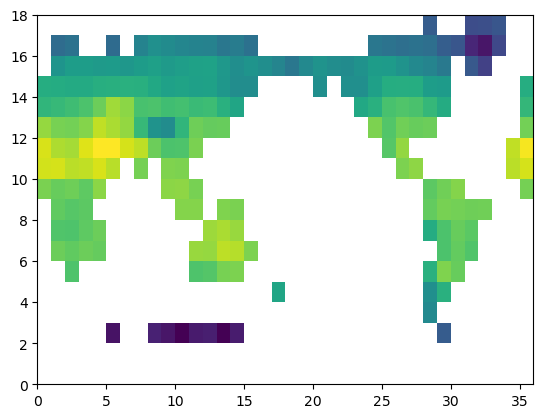

In [9]:
# plt.pcolormesh(AllData.alloutput[0][0,0])

landcheck = np.copy(AllData.alloutput[0][0,0])
landcheck[:2,:] = np.zeros((2,36))+np.nan

plt.pcolormesh(landcheck)

landmask = ~np.isnan(AllData.alloutput[0][0,0])
with open('landmask10x10.pkl','wb') as f:
    pickle.dump(landmask,f)

In [12]:
with open('landmask10x10.pkl','rb') as f:
    landmask1 = pickle.load(f)
landmask1.shape

(18, 36)

### Compute when the CNN first predicts that a record max will occur

In [ ]:
_, _, alltest = AllData.trainvaltest_recordmax(trainvaltest,experiment_era,baselineera,inputlength,outputavgtime,-10,0) # need this to get the GMT vector
_, inputtestGMT, _ = DataHolder.tensortime_onehot(alltest,nclasses=2) # gmt vector

bestaccs = np.empty((len(AllData.output_lat),len(AllData.output_lon),20)) + np.nan
nulls = np.empty((len(AllData.output_lat),len(AllData.output_lon))) + np.nan
nulls2 = np.empty((len(AllData.output_lat),len(AllData.output_lon))) + np.nan

gmt_first_positive = np.empty((5,len(AllData.output_lat),len(AllData.output_lon)))+np.nan
gmt_first_confident = np.empty((5,len(AllData.output_lat),len(AllData.output_lon)))+np.nan
gmt_first_correct = np.empty((5,len(AllData.output_lat),len(AllData.output_lon)))+np.nan

random_chance = np.empty((5,len(AllData.output_lat),len(AllData.output_lon)))+np.nan
cnn_accuracy = np.empty((5,len(AllData.output_lat),len(AllData.output_lon),20))+np.nan

regenerate = False

for ilatsel,latsel in enumerate(AllData.output_lat):

    if (latsel>=0) & (regenerate==False):

        _, _, alltest = AllData.trainvaltest_recordmax(trainvaltest,experiment_era,baselineera,inputlength,outputavgtime,10,0) # and then regenerate the GMT vector when we cross the equation
        _, inputtestGMT, _ = DataHolder.tensortime_onehot(alltest,nclasses=2) 

        regenerate = True
    
    fileopen = "predictions/"+modelfilefront+"avgtime"+str(outputavgtime)+"_allssps_lat"+str(latsel)+"_testing.pkl" # (nlon,nmodels=3,nsamples=3600)

    filecheck = glob.glob(fileopen)
    if len(filecheck) != 0:

        with open(filecheck[0],'rb') as f:
            predictions = pickle.load(f)
        
        filetrue = "predictions/"+modelfilefront+"avgtime"+str(outputavgtime)+"_allssps_lat"+str(latsel)+"_truetesting.pkl"
        with open(filetrue,'rb') as f:
            truths = pickle.load(f)
        
        avgtestpred = np.mean(predictions,axis=1)
        avgtestclass = np.round(avgtestpred)
        avgtestconf = np.where(avgtestpred<0.5,1-avgtestpred,avgtestpred)

        for ilonsel,lonsel in enumerate(AllData.output_lon):

            if np.mean(avgtestpred[ilonsel]) != 0:

                filemetrics = "metrics/"+modelfilefront+"avgtime"+str(outputavgtime)+"_allssps_lat"+str(latsel)+"_lon"+str(lonsel)+"_testing.json"
                with open(filemetrics, 'r') as f:
                    testmetrics = json.load(f)

                bestaccs[ilatsel,ilonsel,:] = testmetrics["test_accuracy"]
                nulls[ilatsel,ilonsel] = np.max(testmetrics["test_class_imbalance"])

                nulls2[ilatsel,ilonsel] = np.max([np.mean(truths[ilonsel]),1-np.mean(truths[ilonsel])])
                # nulls2[ilatsel,ilonsel] = np.max(np.mean(truths[ilonsel]))
        
                for issp,ssp in enumerate(ssplistplot):
                    # if np.mean(avgtestpred[ilonsel]) != 0:

                    inputGMTsel = helpers.grabssp(inputtestGMT.numpy(),issp,AllData.lenhisttime,AllData.lenfuturetime,len(trainvaltest[-1]))
                    predsel = helpers.grabssp(avgtestpred[ilonsel],issp,AllData.lenhisttime,AllData.lenfuturetime,len(trainvaltest[-1]))
                    truesel = helpers.grabssp(truths[ilonsel],issp,AllData.lenhisttime,AllData.lenfuturetime,len(trainvaltest[-1]))

                    predclass = np.round(predsel)
                    predconf = np.where(predsel<0.5,1-predsel,predsel)

                    cnn_accuracy[issp,ilatsel,ilonsel] = helpers.confacc(predclass,truesel,predconf)

                    # first positive prediction
                    gmt_first_positive[issp,ilatsel,ilonsel] = helpers.firstpositive(predsel,inputGMTsel)

                    # first confident, positive prediction
                    gmt_first_confident[issp,ilatsel,ilonsel] = helpers.firstconfident(predsel,inputGMTsel)

                    # first correct, positive prediction 
                    gmt_first_correct[issp,ilatsel,ilonsel] = helpers.firstcorrect(predsel,truesel,inputGMTsel)

                    random_chance[issp,ilatsel,ilonsel] = np.max([np.mean(truesel),1-np.mean(truesel)])



baseline for temp records is 0 50
indices of future period are 104 -4
working on 126
working on 245
working on 370
working on 585


/Users/egor650/Documents/Experiments/predictability-emergence/bin/DataHolder.py:1200: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  outputdata_t = torch.tensor(outputonehotencoded,dtype=torch.float32)


baseline for temp records is 0 50
indices of future period are 104 -4
working on 126
working on 245
working on 370
working on 585


/var/folders/b4/wvswr5295zj_j2dn8xjmpk91cllg7l/T/ipykernel_85418/3288450253.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


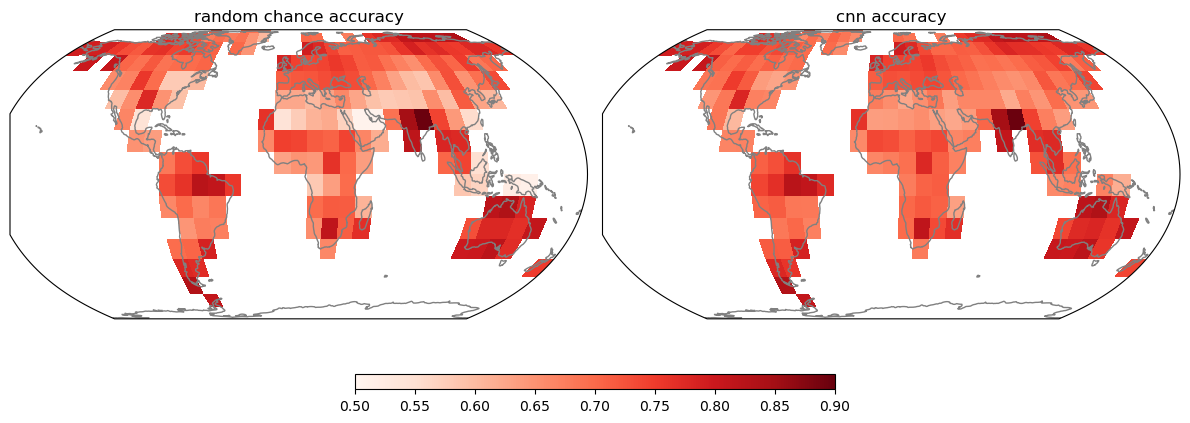

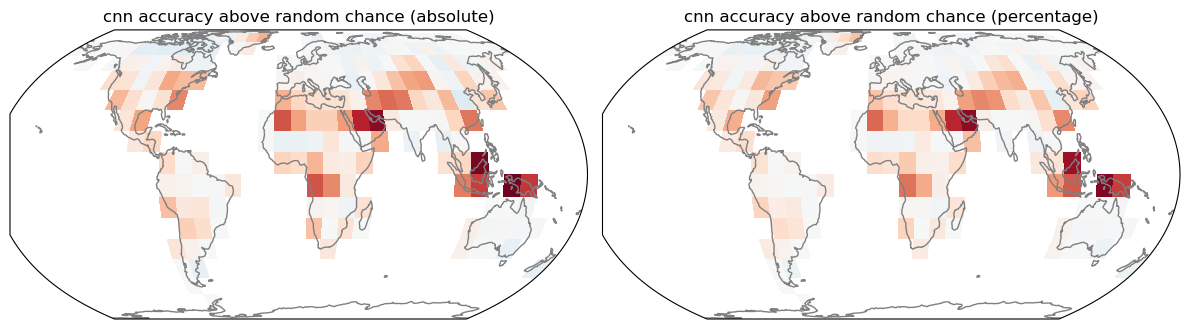

In [4]:
plt.figure(figsize=(12,5))

a1=plt.subplot(1,2,1,projection=ccrs.EqualEarth())
a1.pcolormesh(lonvec+5,latvec+5,nulls2,vmin=0.5,vmax=0.9,cmap='Reds',transform=ccrs.PlateCarree())
a1.coastlines(color='gray')
plt.title('random chance accuracy')

a1=plt.subplot(1,2,2,projection=ccrs.EqualEarth())
c1=a1.pcolormesh(lonvec+5,latvec+5,bestaccs[:,:,0],vmin=0.5,vmax=0.9,cmap='Reds',transform=ccrs.PlateCarree())
a1.coastlines(color='gray')
plt.title('cnn accuracy')

cax = plt.axes((0.3,0.07,0.4,0.03))
cbar = plt.colorbar(c1,cax,orientation='horizontal')

plt.tight_layout()

plt.figure(figsize=(12,5))

a1=plt.subplot(1,2,1,projection=ccrs.EqualEarth())
a1.pcolormesh(lonvec+5,latvec+5,bestaccs[:,:,0]-nulls2,vmin=-0.15,vmax=0.15,cmap='RdBu_r',transform=ccrs.PlateCarree())
a1.coastlines(color='gray')
plt.title('cnn accuracy above random chance (absolute)')

a1=plt.subplot(1,2,2,projection=ccrs.EqualEarth())
a1.pcolormesh(lonvec+5,latvec+5,100*(bestaccs[:,:,0]-nulls2)/nulls2,vmin=-30,vmax=30,cmap='RdBu_r',transform=ccrs.PlateCarree())
a1.coastlines(color='gray')
plt.title('cnn accuracy above random chance (percentage)')

plt.tight_layout()

/var/folders/b4/wvswr5295zj_j2dn8xjmpk91cllg7l/T/ipykernel_85418/179674278.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


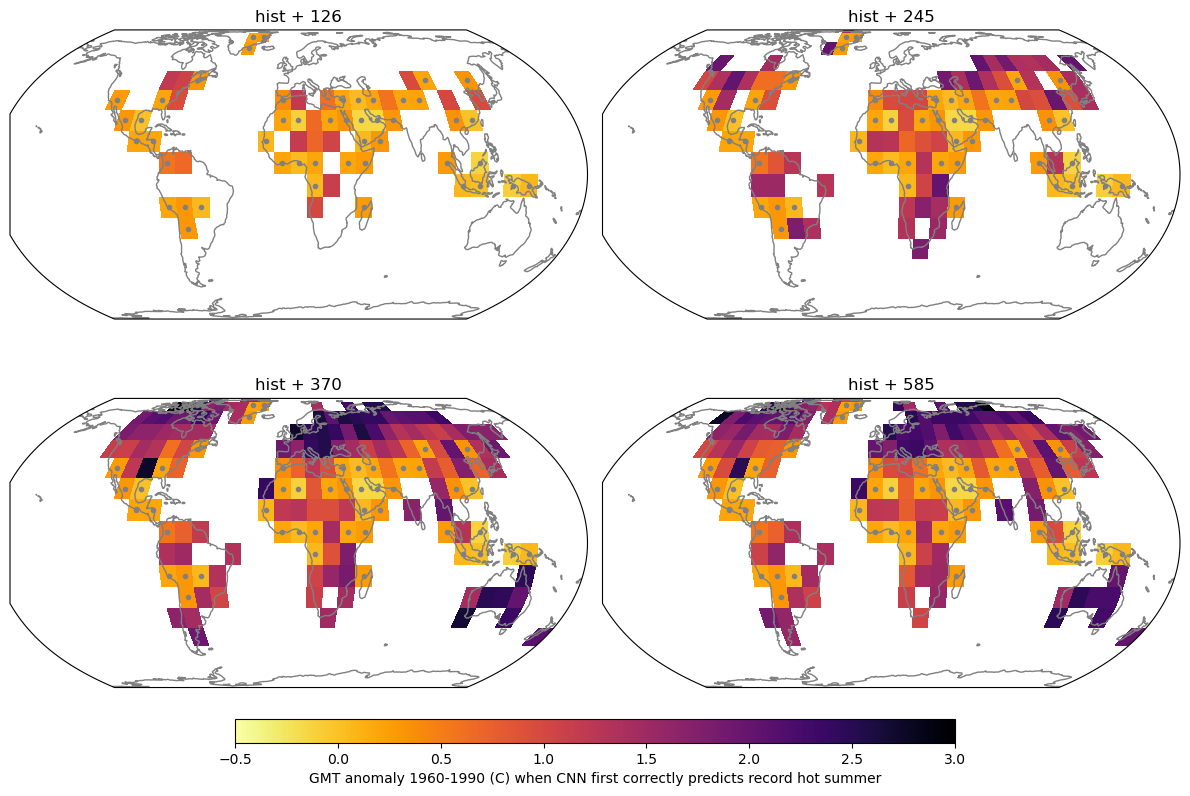

In [5]:
plt.figure(figsize=(12,8))

lonmesh,latmesh = np.meshgrid(lonvec+5,latvec+5)

for iplot in range(4):

    gmt_first_correct_plop = np.concatenate((gmt_first_correct[[0]],gmt_first_correct[[iplot+1]]),axis=0)
    gmt_first_correct_plot = np.nanmin(gmt_first_correct_plop,axis=0)

    histmask = ~np.isnan(gmt_first_correct[0])
    lonhist = lonmesh[histmask]
    lathist = latmesh[histmask]

    ax=plt.subplot(2,2,iplot+1,projection=ccrs.EqualEarth())
    c1=ax.pcolormesh(lonvec+5,latvec+5,gmt_first_correct_plot,vmin=-0.5,vmax=3,cmap='inferno_r',transform=ccrs.PlateCarree())
    ax.scatter(lonhist,lathist,color='gray',marker='.',transform=ccrs.PlateCarree())
    plt.title("hist + " +ssplistplot[iplot+1])
    ax.coastlines(color='gray')

all_first_correct = np.nanmin(gmt_first_correct,axis=0)

cax1 = plt.axes((0.2,0.02,0.6,0.03))
cbar1 = plt.colorbar(c1,cax1,orientation='horizontal')
cbar1.ax.set_xlabel('GMT anomaly 1960-1990 (C) when CNN first correctly predicts record hot summer')


plt.tight_layout()
plt.show()


### A harder baseline model: Beat a logistic regression with parameters: GMT and scenario

In [ ]:
alltrain, allval, alltest = AllData.trainvaltest_recordmax(trainvaltest,experiment_era,baselineera,inputlength,outputavgtime,-20,0)

_, inputtrainGMT, _ = DataHolder.tensortime_onehot(alltrain,nclasses=2)
_, inputvalGMT, _ = DataHolder.tensortime_onehot(allval,nclasses=2)
_, inputtestGMT, _ = DataHolder.tensortime_onehot(alltest,nclasses=2)

inputssptrain,inputsspval,inputssptest = AllData.trainvaltest_recordmax_ssps(trainvaltest,experiment_era,inputlength,outputavgtime,-20)

inputssptrain = np.round((inputssptrain.squeeze()+0.2)*10)
inputsspval = np.round((inputsspval.squeeze()+0.2)*10)
inputssptest = np.round((inputssptest.squeeze()+0.2)*10)

regenerate = False

encoder = OneHotEncoder(sparse_output=False)

# inputssptrain_onehot = encoder.fit_transform(inputssptrain.reshape(-1, 1))
# inputsspval_onehot = encoder.fit_transform(inputsspval.reshape(-1, 1))
# inputssptest_onehot = encoder.fit_transform(inputssptest.reshape(-1, 1))

# inputalltrain = np.hstack([inputtrainGMT.numpy(),inputssptrain_onehot])
# inputallval = np.hstack([inputvalGMT.numpy(),inputsspval_onehot])
# inputalltest = np.hstack([inputtestGMT.numpy(),inputssptest_onehot])

lr_first_positive = np.empty((5,len(AllData.output_lat),len(AllData.output_lon)))+np.nan
lr_first_correct = np.empty((5,len(AllData.output_lat),len(AllData.output_lon)))+np.nan
lr_first_confident = np.empty((5,len(AllData.output_lat),len(AllData.output_lon)))+np.nan

lr_accuracy_ssp = np.empty((5,len(AllData.output_lat),len(AllData.output_lon),20))+np.nan
bs_lr_ssp = np.empty((5,len(AllData.output_lat),len(AllData.output_lon)))+np.nan

lr_accuracy_all = np.empty((len(AllData.output_lat),len(AllData.output_lon),20))+np.nan
bs_lr_all = np.empty((len(AllData.output_lat),len(AllData.output_lon)))+np.nan

sspkeep = 3

for ilatsel,latsel in enumerate(AllData.output_lat):
    print(latsel)

    if (latsel>=0) & (regenerate==False):

        alltrain, allval, alltest = AllData.trainvaltest_recordmax(trainvaltest,experiment_era,baselineera,inputlength,outputavgtime,10,0)
        inputssptrain,inputsspval,inputssptest = AllData.trainvaltest_recordmax_ssps(trainvaltest,experiment_era,inputlength,outputavgtime,latsel)

        _, inputtrainGMT, _ = DataHolder.tensortime_onehot(alltrain,nclasses=2)
        _, inputvalGMT, _ = DataHolder.tensortime_onehot(allval,nclasses=2)
        _, inputtestGMT, _ = DataHolder.tensortime_onehot(alltest,nclasses=2)

        inputssptrain = np.round((inputssptrain.squeeze()+0.2)*10)
        inputsspval = np.round((inputsspval.squeeze()+0.2)*10)
        inputssptest = np.round((inputssptest.squeeze()+0.2)*10)

        # inputssptrain_onehot = encoder.fit_transform(inputssptrain.reshape(-1, 1))
        # inputsspval_onehot = encoder.fit_transform(inputsspval.reshape(-1, 1))
        # inputssptest_onehot = encoder.fit_transform(inputssptest.reshape(-1, 1))

        # inputalltrain = np.hstack([inputtrainGMT.numpy(),inputssptrain_onehot])
        # inputallval = np.hstack([inputvalGMT.numpy(),inputsspval_onehot])
        # inputalltest = np.hstack([inputtestGMT.numpy(),inputssptest_onehot])


        regenerate = True
        
    for ilonsel,lonsel in enumerate(AllData.output_lon):

        outputtrainall, outputvalall, outputtestall = AllData.trainvaltest_recordmax_outputonly(trainvaltest,experiment_era,baselineera,inputlength,outputavgtime,latsel,lonsel)
        
        if (np.mean(outputtrainall)!=0) & (np.mean(outputtrainall)!=1):

            #grab hist only

            histtraingmt = inputtrainGMT[inputssptrain==0]
            histtestgmt = inputtestGMT[inputssptest==0]

            outputtrainhist = outputtrainall[inputssptrain==0]
            outputtesthist = outputtestall[inputssptest==0]

            ssplabelhist = inputssptest[inputssptest==0]

            all_lr_pred = np.empty(1)
            all_lr_conf = np.empty(1)
            all_lr_true = np.empty(1)

            for issp in range(1,5):

                inputtraingmtssp = inputtrainGMT[inputssptrain==issp]
                allinputtraingmt = np.concatenate((histtraingmt,inputtraingmtssp),axis=0)

                outputssptrain = outputtrainall[inputssptrain==issp]
                alloutputtrain = np.concatenate((outputtrainhist,outputssptrain),axis=0)

                inputtestgmtssp = inputtestGMT[inputssptest==issp]
                allinputtestgmt = np.concatenate((histtestgmt,inputtestgmtssp),axis=0)

                outputssptest = outputtestall[inputssptest==issp]
                alloutputtest = np.concatenate((outputtesthist,outputssptest),axis=0)

                ssplabelssp = inputssptest[inputssptest==issp]
                ssplabelsall = np.concatenate((ssplabelhist,ssplabelssp),axis=0)

                # get the CNN predictions

                model = LogisticRegression(random_state=42)

                # Fit the model
                model.fit(allinputtraingmt, alloutputtrain.squeeze())

                y_pred_all = model.predict(allinputtestgmt)
                y_pred_all_prob = model.predict_proba(allinputtestgmt)
                y_conf_all = np.max(allinputtestgmt,axis=1)

                lr_accuracy_ssp[issp-1,ilatsel,ilonsel] = helpers.confacc(y_pred_all.squeeze(),alloutputtest.squeeze(),y_conf_all)

                lr_first_positive[issp-1,ilatsel,ilonsel] = helpers.firstpositive(y_pred_all_prob[:,1],allinputtestgmt.squeeze())
                lr_first_correct[issp-1,ilatsel,ilonsel] = helpers.firstcorrect(y_pred_all_prob[:,1],alloutputtest.squeeze(),allinputtestgmt.squeeze())
                lr_first_confident[issp-1,ilatsel,ilonsel] = helpers.firstconfident(y_pred_all_prob[:,1],allinputtestgmt.squeeze())

                # save predictions of all ssps and only hist for selected ssp

                all_lr_pred = np.append(all_lr_pred,y_pred_all_prob[ssplabelsall==issp,1])
                all_lr_conf = np.append(all_lr_conf,np.max(y_pred_all_prob[ssplabelsall==issp,:],axis=1))
                all_lr_true = np.append(all_lr_true,outputssptest)

                if issp == sspkeep:

                    all_lr_pred = np.append(all_lr_pred,y_pred_all_prob[ssplabelsall==0,1])
                    all_lr_conf = np.append(all_lr_conf,np.max(y_pred_all_prob[ssplabelsall==0,:],axis=1))
                    all_lr_true = np.append(all_lr_true,outputtesthist)


            lr_accuracy_all[ilatsel,ilonsel] = helpers.confacc(np.round(all_lr_pred.squeeze())[1:],all_lr_true.squeeze()[1:],all_lr_conf[1:])



baseline for temp records is 0 50
indices of future period are 104 -4
working on 126
working on 245
working on 370
working on 585


/Users/egor650/Documents/Experiments/predictability-emergence/bin/DataHolder.py:1200: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  outputdata_t = torch.tensor(outputonehotencoded,dtype=torch.float32)


indices of future period are 104 -4
working on 126
working on 245
working on 370
working on 585
-90
-80
-70
-60
-50
-40
-30
-20
-10
0
baseline for temp records is 0 50
indices of future period are 104 -4
working on 126
working on 245
working on 370
working on 585
indices of future period are 104 -4
working on 126
working on 245
working on 370
working on 585


/Users/egor650/Documents/Experiments/predictability-emergence/bin/DataHolder.py:1200: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  outputdata_t = torch.tensor(outputonehotencoded,dtype=torch.float32)


10
20
30
40
50
60
70
80


/var/folders/b4/wvswr5295zj_j2dn8xjmpk91cllg7l/T/ipykernel_85418/758692510.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/b4/wvswr5295zj_j2dn8xjmpk91cllg7l/T/ipykernel_85418/758692510.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


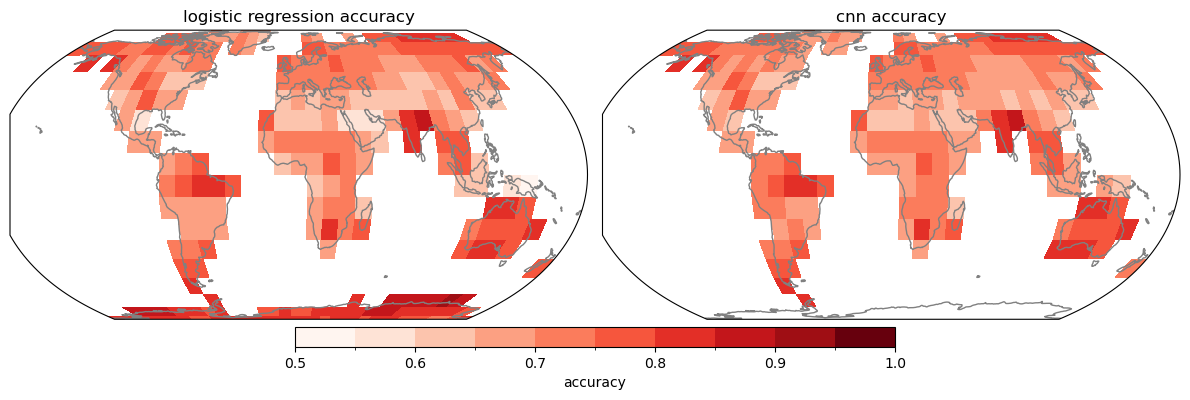

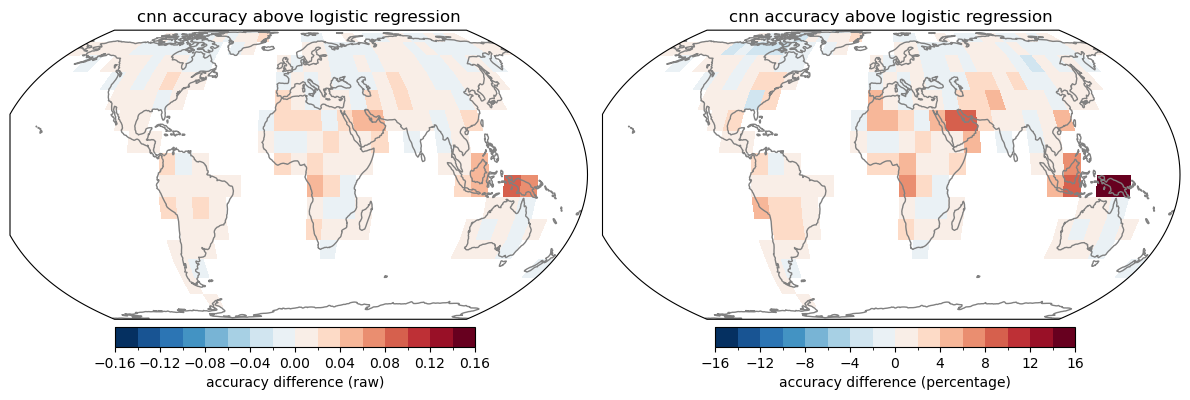

In [15]:
levsacc = np.linspace(0.5,1,11)
cmapacc = plt.get_cmap("Reds")

normacc = BoundaryNorm(levsacc,cmapacc.N)

diff1 = np.linspace(-0.16,0.16,17)
cmapdiff1 = plt.get_cmap("RdBu_r")
normdiff = BoundaryNorm(diff1,cmapdiff1.N)

diffper = np.linspace(-16,16,17)
cmapdiffper = plt.get_cmap("RdBu_r")
normdiffper = BoundaryNorm(diffper,cmapdiffper.N)

plt.figure(figsize=(12,4))

a1=plt.subplot(1,2,1,projection=ccrs.EqualEarth())
c1=a1.pcolormesh(lonvec+5,latvec+5,lr_accuracy_all[:,:,0],norm=normacc,cmap='Reds',transform=ccrs.PlateCarree())
a1.coastlines(color='gray')
plt.title('logistic regression accuracy')

a1=plt.subplot(1,2,2,projection=ccrs.EqualEarth())
a1.pcolormesh(lonvec+5,latvec+5,bestaccs[:,:,0],norm=normacc,cmap='Reds',transform=ccrs.PlateCarree())
a1.coastlines(color='gray')
plt.title('cnn accuracy')

cax = plt.axes((0.25,0.07,0.5,0.05))
cbar1 = plt.colorbar(c1,cax,orientation='horizontal')
cbar1.ax.set_xlabel('accuracy')

plt.tight_layout()


plt.figure(figsize=(12,4))

a1=plt.subplot(1,2,1,projection=ccrs.EqualEarth())
c2=a1.pcolormesh(lonvec+5,latvec+5,bestaccs[:,:,0]-lr_accuracy_all[:,:,0],norm=normdiff,cmap='RdBu_r',transform=ccrs.PlateCarree())
a1.coastlines(color='gray')
plt.title('cnn accuracy above logistic regression')

a1=plt.subplot(1,2,2,projection=ccrs.EqualEarth())
c3=a1.pcolormesh(lonvec+5,latvec+5,100*(bestaccs[:,:,0]-lr_accuracy_all[:,:,0])/lr_accuracy_all[:,:,0],norm=normdiffper,cmap='RdBu_r',transform=ccrs.PlateCarree())
a1.coastlines(color='gray')
plt.title('cnn accuracy above logistic regression')

cax2 = plt.axes((0.1,0.07,0.3,0.05))
cbar2 = plt.colorbar(c2,cax2,orientation='horizontal',ticks=np.arange(-0.16,0.2,0.04))
cbar2.ax.set_xlabel('accuracy difference (raw)')

cax3 = plt.axes((0.6,0.07,0.3,0.05))
cbar3 = plt.colorbar(c3,cax3,orientation='horizontal',ticks=np.arange(-16,20,4))
cbar3.ax.set_xlabel('accuracy difference (percentage)')


plt.tight_layout()

In [8]:
lr_accuracy_all[13,24,0]

0.6886093012806112

In [9]:
bestaccs[13,24,0]

0.6904066501909684

/var/folders/b4/wvswr5295zj_j2dn8xjmpk91cllg7l/T/ipykernel_85418/2716679180.py:31: UserWarning: Adding colorbar to a different Figure <Figure size 1200x400 with 3 Axes> than <Figure size 1200x800 with 5 Axes> which fig.colorbar is called on.
  cbar1 = plt.colorbar(c1,cax1,orientation='horizontal')
/var/folders/b4/wvswr5295zj_j2dn8xjmpk91cllg7l/T/ipykernel_85418/2716679180.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


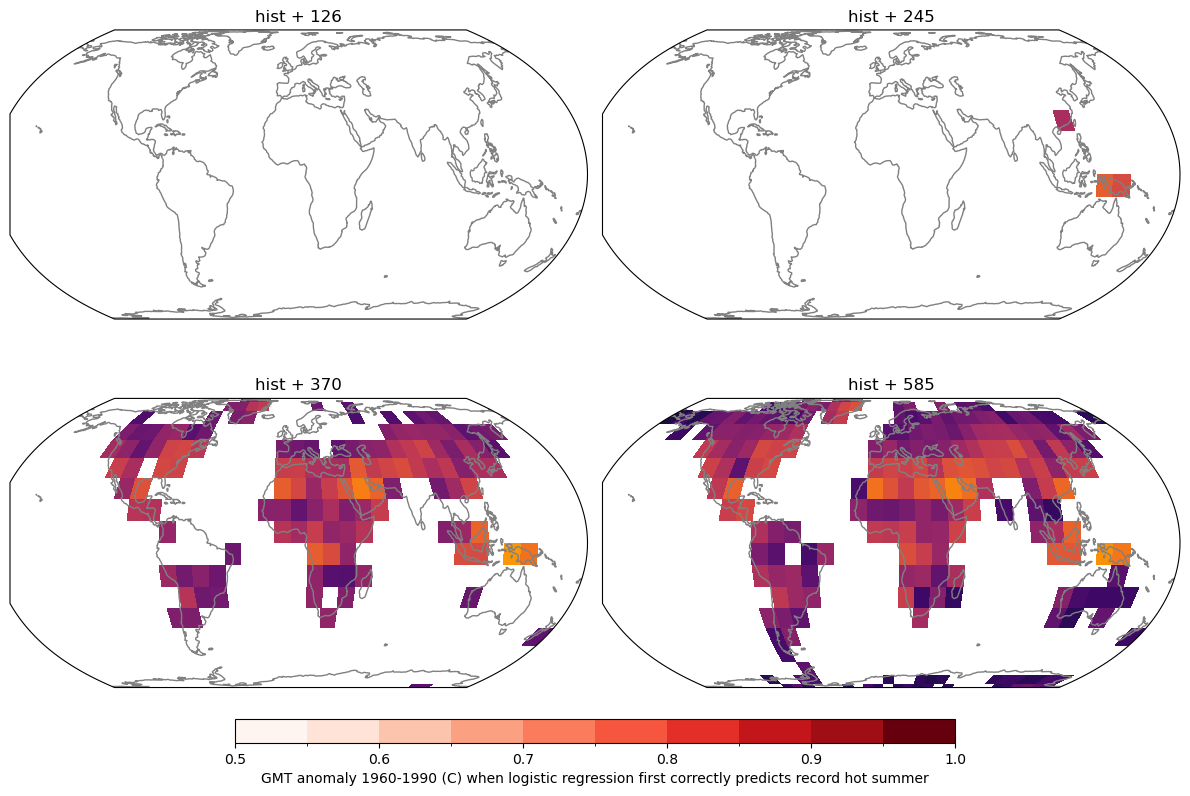

In [10]:
plt.figure(figsize=(12,8))

for iplot in range(4):

    ax=plt.subplot(2,2,iplot+1,projection=ccrs.EqualEarth())
    ax.pcolormesh(lonvec+5,latvec+5,lr_first_correct[iplot],vmin=-0.6,vmax=4,cmap='inferno_r',transform=ccrs.PlateCarree())
    plt.title("hist + "+ssplist[iplot])
    ax.coastlines(color='gray')

# all_lr_first_correct = np.nanmin(lr_first_correct,axis=0)

# mask = np.isnan(lr_first_correct[-1])
# avgfirstcorrect_lr = np.copy(lr_first_correct)

# avgfirstcorrect_lr[np.isnan(lr_first_correct)] = 0
# avgfirstcorrect_lr[~np.isnan(lr_first_correct)] = 1
# all_first_correct_scenario_lr = np.mean(avgfirstcorrect_lr,axis=0)

# all_first_correct_scenario_lr[mask] = np.nan

# ax=plt.subplot(2,3,6,projection=ccrs.EqualEarth())
# c1=ax.pcolormesh(lonvec+5,latvec+5,np.nanmin(lr_first_correct,axis=0),vmin=-0.6,vmax=4,cmap='inferno_r',transform=ccrs.PlateCarree())
# plt.title('all scenarios')
# ax.coastlines(color='gray')

# cax1 = plt.axes((0.2,0.02,0.6,0.03))
# cbar1 = plt.colorbar(c1,cax1,orientation='horizontal')
# cbar1.ax.set_xlabel('GMT anomaly from 1960-1990 (C)')

cax1 = plt.axes((0.2,0.02,0.6,0.03))
cbar1 = plt.colorbar(c1,cax1,orientation='horizontal')
cbar1.ax.set_xlabel('GMT anomaly 1960-1990 (C) when logistic regression first correctly predicts record hot summer')

plt.tight_layout()
plt.show()


### No scenario awareness in logistic regression

I can't decide whether or not to include the scenario as input into the logistic regression model. On the one hand, we don't know what scenario we are on so that means we can't use a scenario indicator as an input when we input observations into the CNN. On the other hand, scenario information is pretty obvious to the CNN (from the SST input). My concern is that comparing a CNN with a scenario-unaware logistic regression model is not a fair comparison because the scenario-unawareness will dilute the logistic regression's skill AND it's decision boundary

In [ ]:
alltrain, allval, alltest = AllData.trainvaltest_recordmax(trainvaltest,experiment_era,baselineera,inputlength,outputavgtime,-20,0)

_, inputtrainGMT, _ = DataHolder.tensortime_onehot(alltrain,nclasses=2)
_, inputvalGMT, _ = DataHolder.tensortime_onehot(allval,nclasses=2)
_, inputtestGMT, _ = DataHolder.tensortime_onehot(alltest,nclasses=2)

inputalltrain = inputtrainGMT.numpy()
inputallval = inputvalGMT.numpy()
inputalltest = inputtestGMT.numpy()

regenerate = False

lr_first_positive = np.empty((5,len(AllData.output_lat),len(AllData.output_lon)))+np.nan
lr_first_correct = np.empty((5,len(AllData.output_lat),len(AllData.output_lon)))+np.nan
lr_first_confident = np.empty((5,len(AllData.output_lat),len(AllData.output_lon)))+np.nan

lr_accuracy_ssp = np.empty((5,len(AllData.output_lat),len(AllData.output_lon),20))+np.nan
bs_lr_ssp = np.empty((5,len(AllData.output_lat),len(AllData.output_lon)))+np.nan

lr_accuracy_all_nossp = np.empty((len(AllData.output_lat),len(AllData.output_lon),20))+np.nan
bs_lr_all = np.empty((len(AllData.output_lat),len(AllData.output_lon)))+np.nan


for ilatsel,latsel in enumerate(AllData.output_lat):
    print(latsel)

    if (latsel>=0) & (regenerate==False):

        alltrain, allval, alltest = AllData.trainvaltest_recordmax(trainvaltest,experiment_era,baselineera,inputlength,outputavgtime,10,0)

        _, inputtrainGMT, _ = DataHolder.tensortime_onehot(alltrain,nclasses=2)
        _, inputvalGMT, _ = DataHolder.tensortime_onehot(allval,nclasses=2)
        _, inputtestGMT, _ = DataHolder.tensortime_onehot(alltest,nclasses=2)

        inputalltrain = inputtrainGMT.numpy()
        inputallval = inputvalGMT.numpy()
        inputalltest = inputtestGMT.numpy()

        regenerate = True
        
    for ilonsel,lonsel in enumerate(AllData.output_lon):

        outputtrainall, outputvalall, outputtestall = AllData.trainvaltest_recordmax_outputonly(trainvaltest,experiment_era,baselineera,inputlength,outputavgtime,latsel,lonsel)

        if (np.mean(outputtrainall)!=0) & (np.mean(outputtrainall)!=1):

            model = LogisticRegression(random_state=42)

            # Fit the model
            model.fit(inputtrainGMT, outputtrainall.squeeze())

            y_pred_all = model.predict(inputtestGMT)
            y_pred_all_prob = model.predict_proba(inputtestGMT)
            y_conf_all = np.max(y_pred_all_prob,axis=1)

            lr_accuracy_all_nossp[ilatsel,ilonsel] = helpers.confacc(y_pred_all.squeeze(),outputtestall.squeeze(),y_conf_all)

            for issp,ssp in enumerate(ssplistplot):

                if np.mean(outputtrainall) != 0:

                    inputtestsel = helpers.grabssp(inputalltest,issp,AllData.lenhisttime,AllData.lenfuturetime,len(trainvaltest[-1]))
                    outputtestsel = helpers.grabssp(outputtestall.squeeze(),issp,AllData.lenhisttime,AllData.lenfuturetime,len(trainvaltest[-1]))

                    y_pred_proba = helpers.grabssp(y_pred_all_prob,issp,AllData.lenhisttime,AllData.lenfuturetime,len(trainvaltest[-1]))
                    y_pred = helpers.grabssp(y_pred_all,issp,AllData.lenhisttime,AllData.lenfuturetime,len(trainvaltest[-1]))

                    y_conf = np.max(y_pred_proba,axis=1)

                    lr_first_positive[issp,ilatsel,ilonsel] = helpers.firstpositive(y_pred_proba[:,1],inputtestsel[:,0])
                    lr_first_correct[issp,ilatsel,ilonsel] = helpers.firstcorrect(y_pred_proba[:,1],outputtestsel,inputtestsel[:,0])
                    lr_first_confident[issp,ilatsel,ilonsel] = helpers.firstconfident(y_pred_proba[:,1],inputtestsel[:,0])



baseline for temp records is 0 50
indices of future period are 104 -4
working on 126
working on 245
working on 370
working on 585


/Users/egor650/Documents/Experiments/predictability-emergence/bin/DataHolder.py:1200: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  outputdata_t = torch.tensor(outputonehotencoded,dtype=torch.float32)


-90
-80
-70
-60
-50
-40
-30
-20
-10
0
baseline for temp records is 0 50
indices of future period are 104 -4
working on 126
working on 245
working on 370
working on 585


/Users/egor650/Documents/Experiments/predictability-emergence/bin/DataHolder.py:1200: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  outputdata_t = torch.tensor(outputonehotencoded,dtype=torch.float32)


10
20
30
40
50
60
70
80


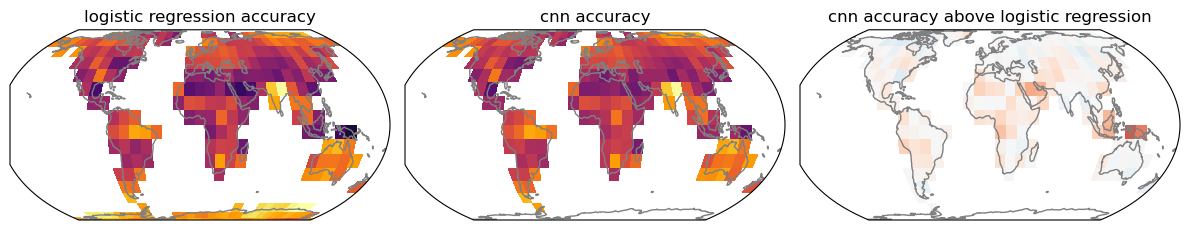

In [ ]:
plt.figure(figsize=(12,5))

a1=plt.subplot(1,3,1,projection=ccrs.EqualEarth())
a1.pcolormesh(lonvec+5,latvec+5,lr_accuracy_all_nossp[:,:,0],vmin=0.5,vmax=0.9,cmap='inferno',transform=ccrs.PlateCarree())
a1.coastlines(color='gray')
plt.title('logistic regression accuracy')

a1=plt.subplot(1,3,2,projection=ccrs.EqualEarth())
a1.pcolormesh(lonvec+5,latvec+5,bestaccs[:,:,0],vmin=0.5,vmax=0.9,cmap='inferno',transform=ccrs.PlateCarree())
a1.coastlines(color='gray')
plt.title('cnn accuracy')

a1=plt.subplot(1,3,3,projection=ccrs.EqualEarth())
a1.pcolormesh(lonvec+5,latvec+5,bestaccs[:,:,0]-lr_accuracy_all_nossp[:,:,0],vmin=-0.15,vmax=0.15,cmap='RdBu_r',transform=ccrs.PlateCarree())
a1.coastlines(color='gray')
plt.title('cnn accuracy above logistic regression')

plt.tight_layout()

In [ ]:
np.nanmax(bestaccs[:,:,0]-lr_accuracy_all[:,:,0])

0.09360054657253469

/var/folders/b4/wvswr5295zj_j2dn8xjmpk91cllg7l/T/ipykernel_34258/4177418948.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


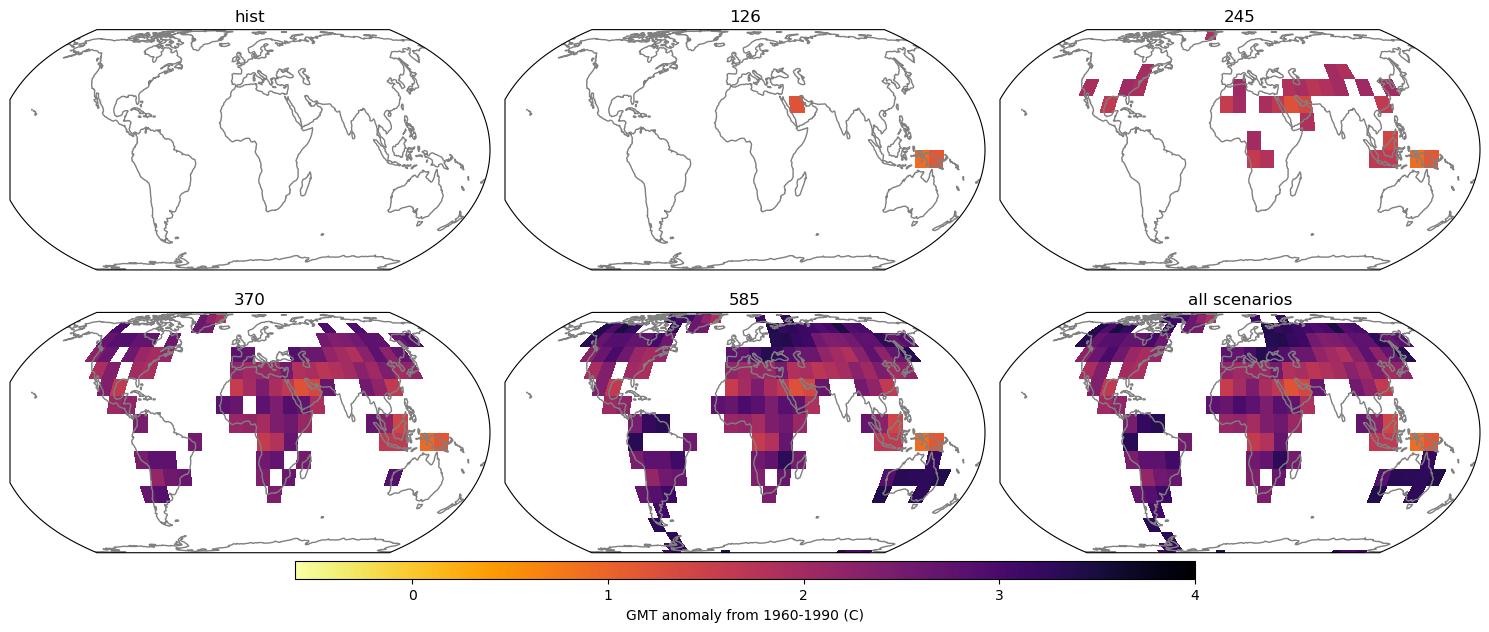

In [ ]:
plt.figure(figsize=(15,6))

for iplot in range(5):

    ax=plt.subplot(2,3,iplot+1,projection=ccrs.EqualEarth())
    ax.pcolormesh(lonvec+5,latvec+5,lr_first_correct[iplot],vmin=-0.6,vmax=4,cmap='inferno_r',transform=ccrs.PlateCarree())
    plt.title(ssplistplot[iplot])
    ax.coastlines(color='gray')

# all_lr_first_correct = np.nanmin(lr_first_correct,axis=0)

# mask = np.isnan(lr_first_correct[-1])
# avgfirstcorrect_lr = np.copy(lr_first_correct)

# avgfirstcorrect_lr[np.isnan(lr_first_correct)] = 0
# avgfirstcorrect_lr[~np.isnan(lr_first_correct)] = 1
# all_first_correct_scenario_lr = np.mean(avgfirstcorrect_lr,axis=0)

# all_first_correct_scenario_lr[mask] = np.nan

ax=plt.subplot(2,3,6,projection=ccrs.EqualEarth())
c1=ax.pcolormesh(lonvec+5,latvec+5,np.nanmin(lr_first_correct,axis=0),vmin=-0.6,vmax=4,cmap='inferno_r',transform=ccrs.PlateCarree())
plt.title('all scenarios')
ax.coastlines(color='gray')

cax1 = plt.axes((0.2,0.02,0.6,0.03))
cbar1 = plt.colorbar(c1,cax1,orientation='horizontal')
cbar1.ax.set_xlabel('GMT anomaly from 1960-1990 (C)')

plt.tight_layout()
plt.show()

In [ ]:
def lightclassweighting(positiveclassimbalance, device):

    classimbalance = np.asarray([(1 - positiveclassimbalance), positiveclassimbalance])
    weights = np.max(classimbalance) / classimbalance

    classratio = np.max(classimbalance) / np.min(classimbalance)
    downweight = (
        0.8 * (classratio - 1) / classratio
    )  # amount to de-emphasize the class imbalance

    if classimbalance[0] < 0.47:
        weights_corrected = [weights[0] - downweight * weights[0], weights[1]]
        weights_corrected = torch.tensor(weights_corrected, dtype=torch.float32).to(
            device
        )

    elif classimbalance[0] > 0.53:
        weights_corrected = [weights[0], weights[1] - downweight * weights[1]]
        weights_corrected = torch.tensor(weights_corrected, dtype=torch.float32).to(
            device
        )

    else:
        weights_corrected = torch.tensor([1, 1], dtype=torch.float32).to(device)

    weights_corrected = weights_corrected / torch.sum(weights_corrected)

    return weights_corrected